## 📘 Guia de Uso - Experimentos Automatizados

### 🎯 Objetivo
Este conjunto de células automatiza o teste de **todas as combinações possíveis de features** (de 3 a 6 features por experimento) e salva cada resultado no **MLflow** para análise posterior.

---

### 🛠️ Como Usar

1. **Execute as células** 

2. **Ajuste o número de combinações** (opcional):
   - Por padrão: testa combinações de **3 a 6 features** = **~33.649 experimentos**
   - Para teste rápido: descomente a linha de `random.sample()` na primeira célula para limitar a 100 combinações
   - Para mais features: mude `range(3, 7)` para `range(1, 7)` (vai aumentar MUITO o tempo)

3. **Execute a célula de geração de combinações** (primeira célula criada)

4. **Execute a célula do loop principal** (segunda célula):
   - Vai rodar por **várias horas** dependendo do número de combinações
   - Progress updates a cada 50 experimentos
   - Todos os resultados são salvos no MLflow automaticamente

5. **Execute a célula de análise** para ver:
   - Top 20 melhores combinações
   - Estatísticas por número de features
   - Gráficos comparativos
   - Features mais importantes

6. **(Opcional)** Execute a célula de Random Forest para testar RF na melhor combinação encontrada

---

### 📊 O Que é Salvo no MLflow

Para **cada experimento**:
- **Parâmetros**: features usadas, número de features, tipo de modelo
- **Métricas**: Recall, Precision, F1-Score, **F2-Score**, AUC
- **Modelo**: Pipeline completo (preprocessor + classifier) salvo para deploy

---

### ⏱️ Tempo Estimado

| Combinações | Tempo Aproximado |
|---|---|
| 100 | ~5-10 minutos |
| 1.000 | ~1 hora |
| 10.000 | ~10 horas |
| 33.649 (completo) | ~30-35 horas |

⚠️ **Dica**: Comece com 100 combinações para testar, depois rode o conjunto completo overnight.

---

### 🔍 Como Acessar os Resultados no MLflow

1. Clique em **"Experiments"** no menu lateral esquerdo do Databricks
2. Procure por **`feature_combinations_experiment`**
3. Você pode:
   - Ordenar por qualquer métrica (F2-Score, AUC, Recall...)
   - Comparar múltiplos experimentos lado a lado
   - Fazer download dos modelos salvos
   - Criar gráficos personalizados

---

### 💡 Dicas de Otimização

**Para acelerar os experimentos:**
- Reduza o range de combinações para 4-6 features: `range(4, 7)`
- Use amostragem aleatória: `random.sample(all_combinations, 1000)`
- Teste primeiro só Logistic Regression (mais rápido que Random Forest)

**Para melhorar a qualidade:**
- Adicione mais modelos no loop (XGBoost, LightGBM...)
- Teste diferentes hiperparâmetros para cada combinação
- Use o conjunto de **validação** (`df_val`, `y_val`) para early stopping

---

### ✅ Próximos Passos

Após encontrar a melhor combinação:
1. Teste com **Random Forest** (célula opcional)
2. Faça **Grid Search** detalhado só nas top 10 combinações
3. Use a melhor combinação para **deploy em produção**
4. Salve o modelo final como **Registered Model** no MLflow
5. Testar um ensaio combinado

# Train Test Split


In [0]:
from sklearn.model_selection import train_test_split

# Load Spark DataFrame and convert to pandas for scikit-learn
df_spark = spark.table('adult_income.adult_income_gold.ad_inc_gold')
df_frame = df_spark.toPandas()

# Realizar split estratificado 60/20/20
y = df_frame['class'].apply(lambda x: 1 if x == '>50K' else 0)

# Primeiro split: 60% treino, 40% restante
df_train, df_temp, y_train_temp, y_temp = train_test_split(
    df_frame, y, test_size=0.4, random_state=42, stratify=y
)

# Segundo split: dividir os 40% em 20% validação e 20% teste
df_val, df_test, y_val_temp, y_test_temp = train_test_split(
    df_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Separar features (X) e target (y) para os conjuntos de treino e teste
X_train = df_train.drop(columns=['class'])
y_train = df_train['class'].apply(lambda x: 1 if x == '>50K' else 0)

X_val = df_val.drop(columns=['class'])
y_val = df_val['class'].apply(lambda x: 1 if x == '>50K' else 0)

X_test = df_test.drop(columns=['class'])
y_test = df_test['class'].apply(lambda x: 1 if x == '>50K' else 0)

print("✅ Conjuntos preparados:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape} | Classe positiva (>50K): {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"  X_val: {X_val.shape}")
print(f"  y_val: {y_val.shape} | Classe positiva (>50K): {y_val.sum()} ({y_val.mean()*100:.1f}%)")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape} | Classe positiva (>50K): {y_test.sum()} ({y_test.mean()*100:.1f}%)")

✅ Conjuntos preparados:
  X_train: (29305, 51)
  y_train: (29305,) | Classe positiva (>50K): 7012 (23.9%)
  X_val: (9768, 51)
  y_val: (9768,) | Classe positiva (>50K): 2337 (23.9%)
  X_test: (9769, 51)
  y_test: (9769,) | Classe positiva (>50K): 2338 (23.9%)


In [0]:
# ✅ VERIFICAÇÃO: Confirmar que os experimentos usam o split correto

print("="*80)
print("📊 VERIFICAÇÃO DO DATA SPLIT")
print("="*80)

print("\n🔢 Tamanhos dos conjuntos:")
print(f"  df_train (Treino):    {df_train.shape[0]:,} registros ({df_train.shape[0]/len(df_frame)*100:.1f}%)")
print(f"  df_val (Validação):   {df_val.shape[0]:,} registros ({df_val.shape[0]/len(df_frame)*100:.1f}%)")
print(f"  df_test (Teste):      {df_test.shape[0]:,} registros ({df_test.shape[0]/len(df_frame)*100:.1f}%)")
print(f"  Total:                {len(df_frame):,} registros")

print("\n✅ CONFIRMAÇÃO:")
print("  - Os experimentos automatizados (Cell 20) TREINAM com 'df_train' (60%)")
print("  - Os experimentos automatizados (Cell 20) AVALIAM com 'df_test' (20%)")
print("  - O conjunto 'df_val' (20%) está disponível para tuning futuro")

print("\n" + "="*80)
print("📝 Código relevante na Cell 20:")
print("="*80)
print("""\n  # Treinar
  X_train_combo = df_train[selected_features]  ← 60% do dataset
  pipeline.fit(X_train_combo, y_train)

  # Prever no conjunto de teste
  X_test_combo = df_test[selected_features]    ← 20% do dataset
  y_pred = pipeline.predict(X_test_combo)
""")

print("="*80)

📊 VERIFICAÇÃO DO DATA SPLIT

🔢 Tamanhos dos conjuntos:
  df_train (Treino):    29,305 registros (60.0%)
  df_val (Validação):   9,768 registros (20.0%)
  df_test (Teste):      9,769 registros (20.0%)
  Total:                48,842 registros

✅ CONFIRMAÇÃO:
  - Os experimentos automatizados (Cell 20) TREINAM com 'df_train' (60%)
  - Os experimentos automatizados (Cell 20) AVALIAM com 'df_test' (20%)
  - O conjunto 'df_val' (20%) está disponível para tuning futuro

📝 Código relevante na Cell 20:

  # Treinar
  X_train_combo = df_train[selected_features]  ← 60% do dataset
  pipeline.fit(X_train_combo, y_train)

  # Prever no conjunto de teste
  X_test_combo = df_test[selected_features]    ← 20% do dataset
  y_pred = pipeline.predict(X_test_combo)



# Pipeline

In [0]:
%pip install xgboost

# vamos importar os transformers
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# vamos definir as colunas
selected_columns = [
    'age',
    'capital-loss',
    'class',
    'edu_x_hours',
    #'education', # => dataleak
    # 'education-num',
    'hours-per-week',
    'is_capital_gain',
    'is_capital_loss',
    #'is_female', # remover redundância de features: is_male + is_female
    'is_from_United-States',
    'is_husb_and_not_in_fam',
    'is_husband',
    'is_male',
    'is_married',
    'is_married_and_not',
    'is_married_notmarried_divorced',
    'is_native-country_missing',
    'is_not_private',
    'is_not_white',
    'is_occupation_missing',
    'is_private',
    'is_white',
    'is_wife',
    # 'marital-status', => dataleak
    'marital_status_ord',
    # 'native-country', => dataleak
    'native-country_ord',
    # 'occupation', => dataleak
    'occupation_ord',
    # 'race', => dataleak
    'race_ord',
    # 'relationship', => dataleak
    'relationship_ord',
    # 'sex', => dataleak
    'sex_ord',
    #'workclass', => dataleak
    'workclass_ord',
    'fnlwgt',
    'rank_continente',
    'risco_total'
]

# variáveis numéricas contínuas -> precisam de imputação + scaling
numeric_features = [
    'age',
    'capital-loss',
    'edu_x_hours',
    'education-num',
    'fnlwgt',
    'hours-per-week',
    'marital_status_ord',
    'native-country_ord',
    'occupation_ord',
    'race_ord',
    'relationship_ord',
    'sex_ord',
    'workclass_ord',
    'rank_continente',
    'risco_total',
]
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# variáveis binárias (já 0/1) -> não precisam de scaling nem encoding,
# só de imputação de segurança (caso existam NaNs residuais)
binary_features = [
    'is_capital_gain',
    'is_capital_loss',
    #'is_female', #remover redundância de features: is_male + is_female
    'is_from_United-States',
    'is_husb_and_not_in_fam',
    'is_husband',
    'is_male',
    'is_married',
    'is_married_and_not',
    'is_married_notmarried_divorced',
    'is_native-country_missing',
    'is_not_private',
    'is_not_white',
    'is_occupation_missing',
    'is_private',
    'is_white',
    'is_wife',
]
binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# vamos combinar os processos
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('bin', binary_transformer, binary_features)
])

# --- Pipeline 1: Regressão Logística (usa o preprocessor com scaling) ---
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(max_iter=250))
])

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


### Aplicar o pipeline

---

# 🧪 Experimentos Automatizados - Combinações de Features

## Objetivo
Testar **automaticamente todas as combinações possíveis de features** (3-6 features por experimento) e salvar todos os resultados no **MLflow** para identificar a melhor combinação que maximiza o **F2-Score** (equilibrando Recall e Precision, com foco em Recall).

## O Que Será Feito
1. ✅ Gerar todas as combinações de 3-6 features
2. ✅ Para cada combinação: treinar Logistic Regression
3. ✅ Avaliar no conjunto de **teste** (df_test)
4. ✅ Salvar métricas e modelo no MLflow
5. ✅ Analisar resultados e identificar as melhores combinações
6. ✅ (Opcional) Testar Random Forest na melhor combinação

---

In [0]:
import itertools
import mlflow
import mlflow.sklearn
from sklearn.metrics import recall_score, precision_score, f1_score, fbeta_score, roc_auc_score
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. Definir TODAS as features disponíveis (excluindo 'class')
all_numeric_features = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-loss',
    'hours-per-week',
    'marital_status_ord',
    'native-country_ord',
    'occupation_ord',
    'race_ord',
    'relationship_ord',
    'sex_ord',
    'workclass_ord',
    'edu_x_hours'
]

all_binary_features = [
    'is_capital_gain',
    'is_capital_loss',
    # 'is_female', remover redundância de features: is_male + is_female
    'is_from_United-States', 
    'is_husb_and_not_in_fam',
    'is_husband', 'is_male',
    'is_married', 'is_married_and_not',
    'is_married_notmarried_divorced',
    'is_native-country_missing',
    'is_not_private', 'is_not_white',
    'is_occupation_missing',
    'is_private',
    'is_white',
     'is_wife'
]

all_features = all_numeric_features + all_binary_features

print(f"Total de features disponíveis: {len(all_features)}")
print(f"Numéricas: {len(all_numeric_features)}")
print(f"Binárias: {len(all_binary_features)}")

# 2. Gerar todas as combinações (de 3 a 6 features para otimizar tempo)
all_combinations = []
for size in range(3, 7):  # 3 a 6 features
    all_combinations.extend(itertools.combinations(all_features, size))

print(f"\nTotal de combinações a testar: {len(all_combinations):,}")
print("Distribuição por tamanho:")
for size in range(3, 7):
    count = len(list(itertools.combinations(all_features, size)))
    print(f"  {size} features: {count:,} combinações")

# OPCIONAL: Se quiser limitar o número de experimentos para teste rápido
# Descomente a linha abaixo para testar apenas 100 combinações aleatórias
# import random
# all_combinations = random.sample(all_combinations, min(50, len(all_combinations)))

print(f"\n⚠️ Nota: {len(all_combinations):,} experimentos serão executados. Isso pode levar várias horas.")
print("Para testar rápido, descomente a linha de amostragem aleatória acima.")

Total de features disponíveis: 29
Numéricas: 13
Binárias: 16

Total de combinações a testar: 621,180
Distribuição por tamanho:
  3 features: 3,654 combinações
  4 features: 23,751 combinações
  5 features: 118,755 combinações
  6 features: 475,020 combinações

⚠️ Nota: 621,180 experimentos serão executados. Isso pode levar várias horas.
Para testar rápido, descomente a linha de amostragem aleatória acima.


In [0]:
from xgboost import XGBClassifier

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, fbeta_score
import random
import pandas as pd


core_features = ['age', 'education-num', 'hours-per-week']  # ajusta às tuas features fixas
candidate_features = [f for f in all_features if f not in core_features]

# versão 6 - calcular scale_pos_weight uma única vez
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight calculado: {scale_pos_weight:.4f}")

# versão1
#xgb_quick = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')

# versão2
# xgb_quick = XGBClassifier(
#     n_estimators=300,
#     max_depth=4,              # limita complexidade da árvore (default=6, sem limite efetivo)
#     learning_rate=0.05,       # mais conservador, compensa com early stopping
#     min_child_weight=5,       # exige mais amostras por folha
#     gamma=0.1,                # ganho mínimo para split (poda)
#     subsample=0.8,            # amostragem de linhas por árvore
#     colsample_bytree=0.8,     # amostragem de colunas por árvore
#     reg_alpha=0.1,            # L1
#     reg_lambda=1.0,           # L2
#     random_state=42,
#     eval_metric='logloss'
# )

# # versão3 (fixa, sem tuning)
# xgb_quick = XGBClassifier(
#     n_estimators=1000,
#     max_depth=4,
#     learning_rate=0.05,
#     min_child_weight=5,
#     gamma=0.1,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     reg_alpha=0.1,
#     reg_lambda=1.0,
#     random_state=42,
#     eval_metric='logloss',
#     early_stopping_rounds=30
# )

# versão 4

random.seed(42)  # reprodutibilidade caso haja sampling em outras partes do notebook

# separar numéricas e binárias dentro de candidate_features
numeric_in_cand = [f for f in candidate_features if f in all_numeric_features]
binary_in_cand = [f for f in candidate_features if f in all_binary_features]

transformers = []
if numeric_in_cand:
    transformers.append(('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_in_cand))
if binary_in_cand:
    transformers.append(('bin', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ]), binary_in_cand))

preprocessor_quick = ColumnTransformer(transformers=transformers)

# fit no treino, transform treino e validação
preprocessor_quick.fit(df_train[candidate_features])
X_train_transformed = preprocessor_quick.transform(df_train[candidate_features])
X_val_transformed = preprocessor_quick.transform(df_val[candidate_features])

param_dist = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 1.5, 2.0],
    'n_estimators': [300, 500, 800]
}

f2_scorer = make_scorer(fbeta_score, beta=2)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# versão 4 alterado na versão 6
#xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight)

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring=f2_scorer,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_transformed, y_train)

print(f"Melhor F2 (CV): {search.best_score_:.4f}")
print(f"Melhores parâmetros: {search.best_params_}")

# versão 4
# best_xgb_params = search.best_params_

# versão 6
best_xgb_params = search.best_params_.copy()
best_xgb_params['scale_pos_weight'] = scale_pos_weight
print(best_xgb_params)

# ====== Refit final com early stopping usando os melhores parâmetros ======
xgb_quick = XGBClassifier(
    **search.best_params_,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=30
)



# versão 1 e 2 
# xgb_quick.fit(df_train[candidate_features], y_train)

# importances = pd.Series(xgb_quick.feature_importances_, index=candidate_features).sort_values(ascending=False)
# display(importances.head(20))


xgb_quick.fit(
    X_train_transformed, y_train,
    eval_set=[(X_val_transformed, y_val)],
    verbose=False
)

print(f"Melhor iteração (early stopping): {xgb_quick.best_iteration}")

# feature_importances_ agora referencia as colunas transformadas, na ordem:
# numéricas primeiro, depois binárias (ordem do ColumnTransformer)
feature_names_transformed = numeric_in_cand + binary_in_cand
importances = pd.Series(xgb_quick.feature_importances_, index=feature_names_transformed).sort_values(ascending=False)
display(importances.head(20))


N_CANDIDATES = 18
optional_features = importances.head(N_CANDIDATES).index.tolist()
print(f"Features candidatas reduzidas: {optional_features}")

scale_pos_weight calculado: 3.1793
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Melhor F2 (CV): 0.7725
Melhores parâmetros: {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}
{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0, 'scale_pos_weight': np.float64(3.1792641186537365)}
Melhor iteração (early stopping): 499


relationship_ord                  0.408211
marital_status_ord                0.222476
edu_x_hours                       0.099813
is_capital_gain                   0.064740
capital-loss                      0.034891
occupation_ord                    0.033686
is_not_private                    0.023671
is_wife                           0.021973
workclass_ord                     0.017230
sex_ord                           0.014696
is_from_United-States             0.013748
fnlwgt                            0.008184
race_ord                          0.007947
is_married_and_not                0.007933
is_native-country_missing         0.007126
native-country_ord                0.006878
is_married_notmarried_divorced    0.006795
is_capital_loss                   0.000000
is_husband                        0.000000
is_male                           0.000000
dtype: float32

Features candidatas reduzidas: ['relationship_ord', 'marital_status_ord', 'edu_x_hours', 'is_capital_gain', 'capital-loss', 'occupation_ord', 'is_not_private', 'is_wife', 'workclass_ord', 'sex_ord', 'is_from_United-States', 'fnlwgt', 'race_ord', 'is_married_and_not', 'is_native-country_missing', 'native-country_ord', 'is_married_notmarried_divorced', 'is_capital_loss']


In [0]:
import itertools
import random
import time
from datetime import datetime
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, fbeta_score

mlflow.set_experiment("/Users/brenofontesx@gmail.com/Adult_Income/adult_income_exp")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

# Gerar combinações SÓ sobre as 18 candidatas (não as 38 originais)
all_combos = []
for size in range(3, 9):
    all_combos.extend(itertools.combinations(optional_features, size))


# OPCIONAL: Se quiser LIMITAR OU ALTERAR o número de experimentos para teste rápido

print(f"Espaço total (sobre {len(optional_features)} candidatas): {len(all_combos):,}")
random.seed(42)  # garante que a amostra de combinações é sempre a mesma
sampled_combinations = random.sample(all_combos, min(50, len(all_combos)))
print(f"Combinações a testar: {len(sampled_combinations)}")

results = []
start_time = time.time()

print(f"Início dos experimentos: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total de experimentos: {len(sampled_combinations):,}\n")

for i, feature_combo in enumerate(sampled_combinations):
    combo_start = time.time()
    selected_features = core_features + list(feature_combo)

    with mlflow.start_run(run_name=f"combo_{i+1}_{len(selected_features)}_features"):
        try:
            numeric_in_combo = [f for f in selected_features if f in all_numeric_features]
            binary_in_combo = [f for f in selected_features if f in all_binary_features]

            transformers = []
            if numeric_in_combo:
                transformers.append(('num', Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler())
                ]), numeric_in_combo))
            if binary_in_combo:
                transformers.append(('bin', Pipeline([
                    ('imputer', SimpleImputer(strategy='most_frequent'))
                ]), binary_in_combo))

            preprocessor_combo = ColumnTransformer(transformers=transformers)
            pipeline = Pipeline([
                ('preprocessor', preprocessor_combo),
                #('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')) versão 1,2,3,4
                ('classifier', XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss'))
            ])

            X_train_combo = df_train[selected_features]

            cv_scores_f2 = cross_val_score(pipeline, X_train_combo, y_train, cv=cv, scoring=f2_scorer, n_jobs=-1)
            cv_scores_recall = cross_val_score(pipeline, X_train_combo, y_train, cv=cv, scoring='recall', n_jobs=-1)
            cv_scores_precision = cross_val_score(pipeline, X_train_combo, y_train, cv=cv, scoring='precision', n_jobs=-1)

            f2_mean, f2_std = cv_scores_f2.mean(), cv_scores_f2.std()
            recall_mean = cv_scores_recall.mean()
            precision_mean = cv_scores_precision.mean()

            pipeline.fit(X_train_combo, y_train)

            mlflow.log_param("num_features", len(selected_features))
            mlflow.log_param("features", ", ".join(selected_features))
            mlflow.log_param("num_numeric_features", len(numeric_in_combo))
            mlflow.log_param("num_binary_features", len(binary_in_combo))
            mlflow.log_param("model_type", "XGBClassifier")
            mlflow.log_param("cv_folds", cv.get_n_splits())

            mlflow.log_metric("f2_cv_mean", f2_mean)
            mlflow.log_metric("f2_cv_std", f2_std)
            mlflow.log_metric("recall_cv_mean", recall_mean)
            mlflow.log_metric("precision_cv_mean", precision_mean)

            mlflow.sklearn.log_model(pipeline, "model")

            results.append({
                'experiment_id': i + 1,
                'num_features': len(selected_features),
                'features': ", ".join(selected_features),
                'recall_cv_mean': recall_mean,
                'precision_cv_mean': precision_mean,
                'f2_cv_mean': f2_mean,
                'f2_cv_std': f2_std,
                'status': 'success'
            })

            if (i + 1) % 50 == 0:
                elapsed = time.time() - start_time
                avg_time = elapsed / (i + 1)
                remaining = avg_time * (len(sampled_combinations) - (i + 1))
                print(f"[{i+1:,}/{len(sampled_combinations):,}] | Tempo médio: {avg_time:.2f}s | Restante: {remaining/60:.1f}min")

        except Exception as e:
            mlflow.log_param("error", str(e))
            results.append({
                'experiment_id': i + 1, 'num_features': len(selected_features),
                'features': ", ".join(selected_features),
                'recall_cv_mean': None, 'precision_cv_mean': None,
                'f2_cv_mean': None, 'f2_cv_std': None,
                'status': f'failed: {str(e)}'
            })
            print(f"[ERROR] Experimento {i+1} falhou: {str(e)}")

total_time = time.time() - start_time
print(f"\n✅ Experimentos concluídos!")
print(f"Tempo total: {total_time/60:.1f} minutos ({total_time/3600:.2f} horas)")
print(f"Experimentos bem-sucedidos: {sum(1 for r in results if r['status'] == 'success')}/{len(results)}")

Espaço total (sobre 18 candidatas): 106,590
Combinações a testar: 50
Início dos experimentos: 2026-09-12 15:59:12
Total de experimentos: 50



2026/09/12 15:59:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-86de1988-cb23.cloud.databricks.com/ml/experiments/1557144449718682/models/m-35b964426f57415bb6254d8d0944b53b?o=7474648411943627
2026/09/12 15:59:25 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.
2026/09/12 15:59:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-86de1988-cb23.cloud.databricks.com/ml/experiments/1557144449718682/models/m-44470fcc704e4bed98ae161869278f7b?o=747464841194

[50/50] | Tempo médio: 14.48s | Restante: 0.0min

✅ Experimentos concluídos!
Tempo total: 12.1 minutos (0.20 horas)
Experimentos bem-sucedidos: 50/50


TOP 20 COMBINAÇÕES DE FEATURES (ordenado por F2-Score)


experiment_id,num_features,features,recall_cv_mean,precision_cv_mean,f2_cv_mean,f2_cv_std
22,11,"age, education-num, hours-per-week, relationship_ord, marital_status_ord, is_capital_gain, capital-loss, is_wife, workclass_ord, fnlwgt, is_native-country_missing",0.8720770551792928,0.5452860012943809,0.7786955578649734,0.007183123939884287
30,11,"age, education-num, hours-per-week, relationship_ord, edu_x_hours, is_capital_gain, capital-loss, workclass_ord, is_native-country_missing, native-country_ord, is_capital_loss",0.8685123482083938,0.5455666929479767,0.7765409250360992,0.00826231318177992
13,11,"age, education-num, hours-per-week, relationship_ord, edu_x_hours, is_capital_gain, capital-loss, sex_ord, is_native-country_missing, native-country_ord, is_capital_loss",0.8676559197074132,0.5448853077371083,0.7757249451603171,0.0067773263677238125
45,9,"age, education-num, hours-per-week, marital_status_ord, is_capital_gain, occupation_ord, is_wife, is_native-country_missing, is_capital_loss",0.8659437744470531,0.5432773024888561,0.7739283663548415,0.006990430329848811
11,11,"age, education-num, hours-per-week, marital_status_ord, is_capital_gain, occupation_ord, is_not_private, workclass_ord, sex_ord, is_from_United-States, native-country_ord",0.8643756043448775,0.5438804760045199,0.773197027172439,0.007093703088447143
15,11,"age, education-num, hours-per-week, relationship_ord, is_capital_gain, occupation_ord, is_not_private, is_from_United-States, fnlwgt, is_married_and_not, is_native-country_missing",0.8620944725130478,0.5417525704818148,0.7708468815113803,0.008016375531412259
34,11,"age, education-num, hours-per-week, relationship_ord, is_capital_gain, occupation_ord, is_not_private, is_wife, race_ord, is_native-country_missing, native-country_ord",0.8620947775451626,0.541382882498433,0.7706921715743655,0.007270316262834635
40,9,"age, education-num, hours-per-week, marital_status_ord, is_capital_gain, sex_ord, is_native-country_missing, is_married_notmarried_divorced, is_capital_loss",0.8663719378588576,0.5344541261787634,0.770626131304239,0.008289047531540703
35,10,"age, education-num, hours-per-week, relationship_ord, edu_x_hours, capital-loss, occupation_ord, is_wife, race_ord, is_native-country_missing",0.8629479523702519,0.5387939628637293,0.770207552735074,0.007450299721933438
44,10,"age, education-num, hours-per-week, relationship_ord, edu_x_hours, capital-loss, occupation_ord, is_not_private, race_ord, is_capital_loss",0.8626633574071457,0.5390191475432692,0.7701288572118016,0.008220437264474608



ESTATÍSTICAS GERAIS

Métricas médias por número de features:


"('recall_cv_mean', 'mean')","('recall_cv_mean', 'std')","('recall_cv_mean', 'min')","('recall_cv_mean', 'max')","('precision_cv_mean', 'mean')","('precision_cv_mean', 'std')","('precision_cv_mean', 'min')","('precision_cv_mean', 'max')","('f2_cv_mean', 'mean')","('f2_cv_mean', 'std')","('f2_cv_mean', 'min')","('f2_cv_mean', 'max')","('f2_cv_std', 'mean')","('f2_cv_std', 'std')","('f2_cv_std', 'min')","('f2_cv_std', 'max')"
0.8186902327700069,0.035597858953835985,0.7942078468494758,0.8595263054611934,0.48966744318326194,0.03829783821907284,0.4634236129861537,0.533614193150689,0.7215321844739128,0.0386664818354444,0.6949534423871813,0.7658904252963035,0.009443104752369237,0.0019277809554006143,0.0073394319320811635,0.01112522674135133
0.8272090476592344,0.029736777835134245,0.7879306926364231,0.8578152786519209,0.4899180325671161,0.03948149187066836,0.4487213516395627,0.5323889671745909,0.7267134681514705,0.03523047699849854,0.6842156763560575,0.764295579504725,0.008901552446556832,0.002099889557957466,0.007239601395877464,0.012149855833617097
0.843803518308197,0.022751361117314985,0.7996286742389194,0.8663719378588576,0.511321663153743,0.031653992778518165,0.4544228123236234,0.5432773024888561,0.7464535071648961,0.027757228192801187,0.6940970396014048,0.7739283663548415,0.00724901774898752,0.0012960266329752168,0.004971510100263897,0.0086330495456025
0.8477179734073003,0.017995594790948328,0.8248716068990131,0.8650880576876736,0.5205139861793627,0.019416880794019434,0.4952289452315114,0.5390191475432692,0.7529614678113561,0.01945491601265906,0.7279115614857952,0.770207552735074,0.006621003467830798,0.0016230842333867755,0.003987315278621122,0.009112363088142847
0.8487664145406775,0.019916331429385134,0.8023389862562696,0.8720770551792928,0.522080016814174,0.02528844804107915,0.45688574755016675,0.5455666929479767,0.7542100707993517,0.023198099412759937,0.6968488215356595,0.7786955578649734,0.006777113968031312,0.00179021632207648,0.002255264577863205,0.008665565429655272



⭐ MELHOR COMBINAÇÃO GERAL (F2-Score)
Experimento ID: 22
Número de features: 11
Features: age, education-num, hours-per-week, relationship_ord, marital_status_ord, is_capital_gain, capital-loss, is_wife, workclass_ord, fnlwgt, is_native-country_missing

Métricas:
  Recall (CV): 0.8721
  Precision (CV): 0.5453
  F2-Score (CV): 0.7787
  F2-Score Std (CV): 0.0072


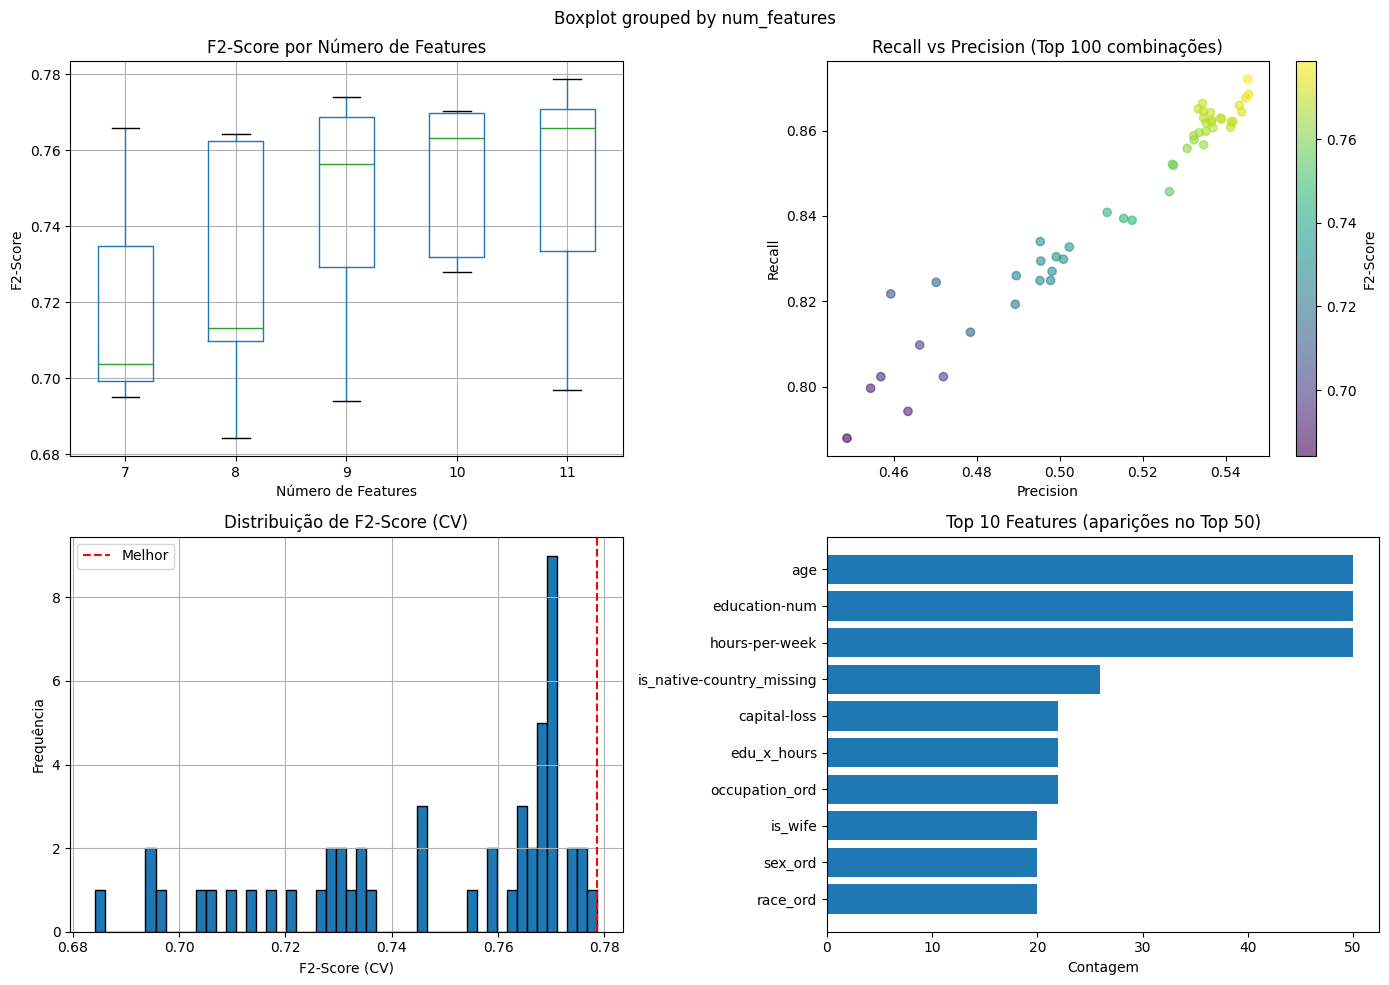


✅ Resultados salvos em: feature_combination_results.csv


In [0]:
import pandas as pd
import mlflow

# 5. Análise dos resultados

# Verificar se 'results' foi populado corretamente
if not isinstance(results, list) or len(results) == 0 or results == [...]:
    print("⚠️ A variável 'results' não está disponível na sessão.")
    print("📥 Carregando resultados dos logs do MLflow...\n")

    # Carregar resultados do MLflow
    mlflow.set_experiment("/Users/brenofontesx@gmail.com/Adult_Income/adult_income_exp")
    experiment = mlflow.get_experiment_by_name("/Users/brenofontesx@gmail.com/Adult_Income/adult_income_exp")

    if experiment is None:
        print("❌ ERRO: Experimento MLflow não encontrado.")
        print("\n📋 SOLUÇÃO:")
        print("   Execute Cell Run All Experiment primeiro para gerar os experimentos.")
        print("\n⚠️ NOTA: Cell pode levar várias horas dependendo do número de experimentos.")
        raise ValueError("Experimento MLflow não encontrado")

    # Buscar todas as runs do experimento
    runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

    if len(runs) == 0:
        print("❌ ERRO: Nenhuma run encontrada no experimento MLflow.")
        print("\n📋 SOLUÇÃO:")
        print("   Execute Cell Run All Experiments primeiro para gerar os experimentos.")
        raise ValueError("Nenhuma run encontrada no MLflow")

    # Reconstruir o DataFrame de resultados a partir das runs do MLflow
    results_data = []
    for idx, run in runs.iterrows():
        try:
            results_data.append({
                'experiment_id': int(run['tags.mlflow.runName'].split('_')[1]) if 'tags.mlflow.runName' in run and run['tags.mlflow.runName'] else idx + 1,
                'num_features': int(run['params.num_features']) if 'params.num_features' in run and pd.notna(run['params.num_features']) else None,
                'features': run['params.features'] if 'params.features' in run else '',
                'recall_cv_mean': run['metrics.recall_cv_mean'] if 'metrics.recall_cv_mean' in run else None,
                'precision_cv_mean': run['metrics.precision_cv_mean'] if 'metrics.precision_cv_mean' in run else None,
                'f2_cv_mean': run['metrics.f2_cv_mean'] if 'metrics.f2_cv_mean' in run else None,
                'f2_cv_std': run['metrics.f2_cv_std'] if 'metrics.f2_cv_std' in run else None,
                'status': 'success' if pd.notna(run.get('metrics.f2_cv_mean')) else 'failed'
            })
        except Exception as e:
            # Skip runs que não têm os dados esperados
            continue

    results_df = pd.DataFrame(results_data)
    print(f"✅ Carregados {len(results_df)} experimentos do MLflow.\n")
else:
    results_df = pd.DataFrame(results)

# Verificar se o DataFrame tem as colunas esperadas
if 'status' not in results_df.columns:
    print("❌ ERRO: DataFrame 'results_df' não contém a coluna 'status'.")
    print("\nColunas disponíveis:", results_df.columns.tolist())
    raise ValueError("Coluna 'status' não encontrada em results_df")

# Filtrar apenas experimentos bem-sucedidos
successful_results = results_df[results_df['status'] == 'success'].copy()

if len(successful_results) > 0:
    # Ordenar por F2-Score (métrica que favorece recall)
    successful_results = successful_results.sort_values('f2_cv_mean', ascending=False)

    print("="*80)
    print("TOP 20 COMBINAÇÕES DE FEATURES (ordenado por F2-Score)")
    print("="*80)
    display(successful_results[['experiment_id', 'num_features', 'features', 'recall_cv_mean', 'precision_cv_mean', 'f2_cv_mean', 'f2_cv_std']].head(20))

    print("\n" + "="*80)
    print("ESTATÍSTICAS GERAIS")
    print("="*80)
    print(f"\nMétricas médias por número de features:")
    stats_by_size = successful_results.groupby('num_features')[['recall_cv_mean', 'precision_cv_mean', 'f2_cv_mean', 'f2_cv_std']].agg(['mean', 'std', 'min', 'max'])
    display(stats_by_size)

    # Melhor combinação geral
    best_combo = successful_results.iloc[0]
    print("\n" + "="*80)
    print("⭐ MELHOR COMBINAÇÃO GERAL (F2-Score)")
    print("="*80)
    print(f"Experimento ID: {best_combo['experiment_id']}")
    print(f"Número de features: {best_combo['num_features']}")
    print(f"Features: {best_combo['features']}")
    print(f"\nMétricas:")
    print(f"  Recall (CV): {best_combo['recall_cv_mean']:.4f}")
    print(f"  Precision (CV): {best_combo['precision_cv_mean']:.4f}")
    print(f"  F2-Score (CV): {best_combo['f2_cv_mean']:.4f}")
    print(f"  F2-Score Std (CV): {best_combo['f2_cv_std']:.4f}")

    # Visualização
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Gráfico 1: F2-Score por número de features
    successful_results.boxplot(column='f2_cv_mean', by='num_features', ax=axes[0, 0])
    axes[0, 0].set_title('F2-Score por Número de Features')
    axes[0, 0].set_xlabel('Número de Features')
    axes[0, 0].set_ylabel('F2-Score')

    # Gráfico 2: Recall vs Precision (top 100)
    top_100 = successful_results.head(100)
    scatter = axes[0, 1].scatter(top_100['precision_cv_mean'], top_100['recall_cv_mean'],
                                  c=top_100['f2_cv_mean'], cmap='viridis', alpha=0.6)
    axes[0, 1].set_title('Recall vs Precision (Top 100 combinações)')
    axes[0, 1].set_xlabel('Precision')
    axes[0, 1].set_ylabel('Recall')
    plt.colorbar(scatter, ax=axes[0, 1], label='F2-Score')

    # Gráfico 3: Distribuição de F2-Score (CV)
    successful_results['f2_cv_mean'].hist(bins=50, ax=axes[1, 0], edgecolor='black')
    axes[1, 0].set_title('Distribuição de F2-Score (CV)')
    axes[1, 0].set_xlabel('F2-Score (CV)')
    axes[1, 0].set_ylabel('Frequência')
    axes[1, 0].axvline(best_combo['f2_cv_mean'], color='red', linestyle='--', label='Melhor')
    axes[1, 0].legend()

    # Gráfico 4: Top 10 features (contagem de aparições no top 50)
    top_50 = successful_results.head(50)
    all_top_features = []
    for features_str in top_50['features']:
        all_top_features.extend([f.strip() for f in features_str.split(',')])

    from collections import Counter
    feature_counts = Counter(all_top_features)
    top_features_df = pd.DataFrame(feature_counts.most_common(10), columns=['Feature', 'Count'])

    axes[1, 1].barh(top_features_df['Feature'], top_features_df['Count'])
    axes[1, 1].set_title('Top 10 Features (aparições no Top 50)')
    axes[1, 1].set_xlabel('Contagem')
    axes[1, 1].invert_yaxis()

    plt.tight_layout()
    plt.show()

    # Salvar resultados em CSV
    results_csv_path = "feature_combination_results.csv"
    successful_results.to_csv(results_csv_path, index=False)
    print(f"\n✅ Resultados salvos em: {results_csv_path}")

else:
    print("⚠️ Nenhum experimento bem-sucedido encontrado.")

🔍 ANÁLISE: TREINO vs TESTE - Melhor Combinação

📋 Melhor combinação (Experimento 22):
   Features (11): ['age', 'education-num', 'hours-per-week', 'relationship_ord', 'marital_status_ord', 'is_capital_gain', 'capital-loss', 'is_wife', 'workclass_ord', 'fnlwgt', 'is_native-country_missing']
   F2-Score (CV): 0.7787


📊 COMPARAÇÃO: TREINO vs TESTE


,Métrica,Treino (60%),Teste (20%),GAP (Treino - Teste),GAP %
0,Recall,0.8866,0.8828,0.0038,0.43%
1,Precision,0.5522,0.5414,0.0108,1.95%
2,F1-Score,0.6806,0.6712,0.0093,1.37%
3,F2-Score,0.7908,0.7840,0.0069,0.87%
4,AUC,0.9133,0.9039,0.0094,1.03%



🔍 INTERPRETAÇÃO

📈 GAP Médio (todas métricas): 0.0080

✅ BOA GENERALIZAÇÃO (F2 Gap ≈ 0)
   O modelo não está sofrendo overfitting significativo.
   A performance no treino e teste é similar.


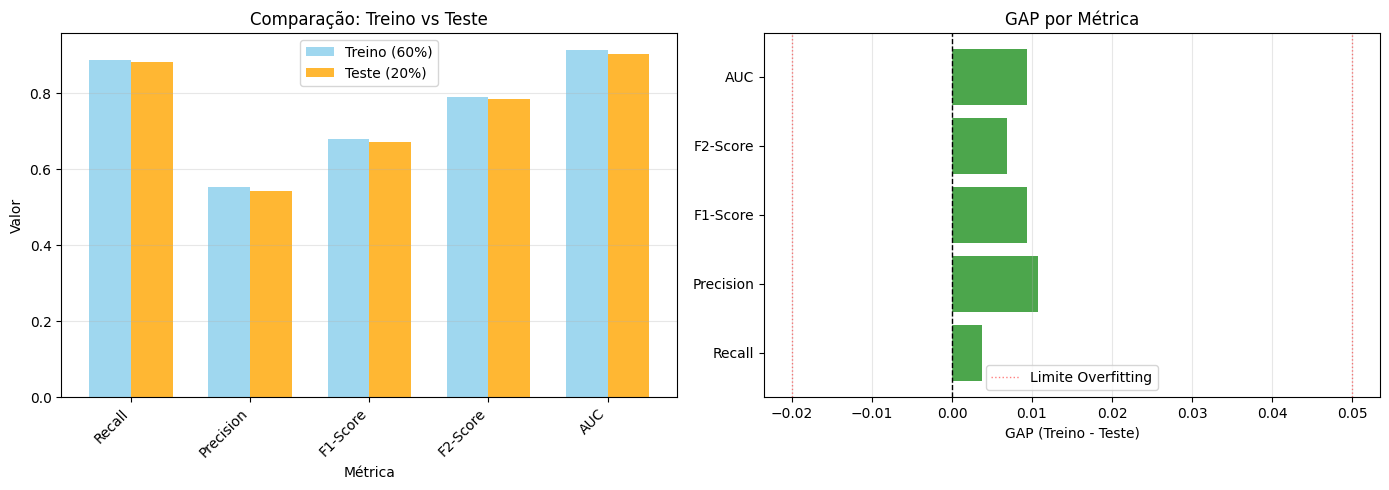


✅ ANÁLISE CONCLUÍDA


In [0]:
# Comparar performance Treino vs Teste APENAS da melhor combinação

if len(successful_results) > 0:
    print("="*100)
    print("🔍 ANÁLISE: TREINO vs TESTE - Melhor Combinação")
    print("="*100)

    # Pegar a melhor combinação (maior F2-Score no teste)
    best_combo = successful_results.iloc[0]
    best_features_str = best_combo['features']
    best_features = [f.strip() for f in best_features_str.split(',')]

    print(f"\n📋 Melhor combinação (Experimento {best_combo['experiment_id']}):")
    print(f"   Features ({len(best_features)}): {best_features}")
    print(f"   F2-Score (CV): {best_combo['f2_cv_mean']:.4f}\n")

    # Separar features numéricas e binárias
    numeric_in_combo = [f for f in best_features if f in all_numeric_features]
    binary_in_combo = [f for f in best_features if f in all_binary_features]

    # Criar preprocessor
    transformers = []
    if numeric_in_combo:
        numeric_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])
        transformers.append(('num', numeric_transformer, numeric_in_combo))

    if binary_in_combo:
        binary_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent'))
        ])
        transformers.append(('bin', binary_transformer, binary_in_combo))

    preprocessor_best = ColumnTransformer(transformers=transformers)

    # Criar pipeline
    pipeline_best = Pipeline(steps=[
    ('preprocessor', preprocessor_best),
    # ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')) versão 1,2,3,4
    ('classifier',XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss'))
    ])

    # ====== TREINAR ======
    X_train_best = df_train[best_features]
    pipeline_best.fit(X_train_best, y_train)

    # ====== AVALIAR NO TREINO ======
    y_train_pred = pipeline_best.predict(X_train_best)
    y_train_pred_proba = pipeline_best.predict_proba(X_train_best)[:, 1]

    recall_train = recall_score(y_train, y_train_pred)
    precision_train = precision_score(y_train, y_train_pred)
    f1_train = f1_score(y_train, y_train_pred)
    f2_train = fbeta_score(y_train, y_train_pred, beta=2)
    auc_train = roc_auc_score(y_train, y_train_pred_proba)

    # ====== AVALIAR NO TESTE ======
    X_test_best = df_test[best_features]
    y_test_pred = pipeline_best.predict(X_test_best)
    y_test_pred_proba = pipeline_best.predict_proba(X_test_best)[:, 1]

    recall_test = recall_score(y_test, y_test_pred)
    precision_test = precision_score(y_test, y_test_pred)
    f1_test = f1_score(y_test, y_test_pred)
    f2_test = fbeta_score(y_test, y_test_pred, beta=2)
    auc_test = roc_auc_score(y_test, y_test_pred_proba)

    # ====== CALCULAR GAP ======
    recall_gap = recall_train - recall_test
    precision_gap = precision_train - precision_test
    f1_gap = f1_train - f1_test
    f2_gap = f2_train - f2_test
    auc_gap = auc_train - auc_test

    # Criar DataFrame de comparação
    comparison_data = {
        'Métrica': ['Recall', 'Precision', 'F1-Score', 'F2-Score', 'AUC'],
        'Treino (60%)': [recall_train, precision_train, f1_train, f2_train, auc_train],
        'Teste (20%)': [recall_test, precision_test, f1_test, f2_test, auc_test],
        'GAP (Treino - Teste)': [recall_gap, precision_gap, f1_gap, f2_gap, auc_gap],
        'GAP %': [
            (recall_gap/recall_train*100) if recall_train > 0 else 0,
            (precision_gap/precision_train*100) if precision_train > 0 else 0,
            (f1_gap/f1_train*100) if f1_train > 0 else 0,
            (f2_gap/f2_train*100) if f2_train > 0 else 0,
            (auc_gap/auc_train*100) if auc_train > 0 else 0
        ]
    }

    comparison_df = pd.DataFrame(comparison_data)

    print("\n" + "="*100)
    print("📊 COMPARAÇÃO: TREINO vs TESTE")
    print("="*100)
    display(comparison_df.style.format({
        'Treino (60%)': '{:.4f}',
        'Teste (20%)': '{:.4f}',
        'GAP (Treino - Teste)': '{:.4f}',
        'GAP %': '{:.2f}%'
    }))

    # Interpretação do GAP
    print("\n" + "="*100)
    print("🔍 INTERPRETAÇÃO")
    print("="*100)

    avg_gap = comparison_df['GAP (Treino - Teste)'].mean()

    print(f"\n📈 GAP Médio (todas métricas): {avg_gap:.4f}\n")

    if f2_gap > 0.05:
        print("⚠️ OVERFITTING DETECTADO (F2 Gap > 0.05)")
        print("   O modelo performa significativamente melhor no treino que no teste.")
        print("   Sugestões:")
        print("   • Usar regularização mais forte (reduzir C na Logistic Regression)")
        print("   • Reduzir número de features")
        print("   • Usar cross-validation")
    elif f2_gap < -0.02:
        print("⚠️ INCONSISTÊNCIA (F2 Gap < -0.02)")
        print("   O modelo performa melhor no teste que no treino (raro).")
        print("   Verificar possíveis problemas nos dados.")
    else:
        print("✅ BOA GENERALIZAÇÃO (F2 Gap ≈ 0)")
        print("   O modelo não está sofrendo overfitting significativo.")
        print("   A performance no treino e teste é similar.")

    # Visualização
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico 1: Comparação Treino vs Teste
    metrics = comparison_df['Métrica']
    train_values = comparison_df['Treino (60%)']
    test_values = comparison_df['Teste (20%)']

    x = range(len(metrics))
    width = 0.35

    axes[0].bar([i - width/2 for i in x], train_values, width, label='Treino (60%)', alpha=0.8, color='skyblue')
    axes[0].bar([i + width/2 for i in x], test_values, width, label='Teste (20%)', alpha=0.8, color='orange')
    axes[0].set_xlabel('Métrica')
    axes[0].set_ylabel('Valor')
    axes[0].set_title('Comparação: Treino vs Teste')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics, rotation=45, ha='right')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')

    # Gráfico 2: GAP por Métrica
    gap_values = comparison_df['GAP (Treino - Teste)']
    colors = ['red' if gap > 0.05 else 'green' if abs(gap) < 0.02 else 'orange' for gap in gap_values]

    axes[1].barh(metrics, gap_values, color=colors, alpha=0.7)
    axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
    axes[1].axvline(0.05, color='red', linestyle=':', linewidth=1, alpha=0.5, label='Limite Overfitting')
    axes[1].axvline(-0.02, color='red', linestyle=':', linewidth=1, alpha=0.5)
    axes[1].set_xlabel('GAP (Treino - Teste)')
    axes[1].set_title('GAP por Métrica')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

    print("\n" + "="*100)
    print("✅ ANÁLISE CONCLUÍDA")
    print("="*100)

else:
    print("⚠️ Execute primeiro a célula 21 (experimentos) para ter resultados disponíveis.")

## Train vs Test vs Validation Analysis

📊 ANÁLISE COMPLETA: TREINO (60%) vs VALIDAÇÃO (20%) vs TESTE (20%)

📋 Melhor combinação (Experimento 22):
   Features (11): ['age', 'education-num', 'hours-per-week', 'relationship_ord', 'marital_status_ord', 'is_capital_gain', 'capital-loss', 'is_wife', 'workclass_ord', 'fnlwgt', 'is_native-country_missing']


📊 COMPARAÇÃO: TREINO vs VALIDAÇÃO vs TESTE


,Métrica,Treino (60%),Validação (20%),Teste (20%),Desvio Padrão,Range
0,Recall,0.8866,0.8772,0.8828,0.0047,0.0094
1,Precision,0.5522,0.5438,0.5414,0.0057,0.0108
2,F1-Score,0.6806,0.6714,0.6712,0.0054,0.0093
3,F2-Score,0.7908,0.7814,0.7840,0.0049,0.0095
4,AUC,0.9133,0.9043,0.9039,0.0053,0.0094



🔍 INTERPRETAÇÃO

📈 Desvio Padrão Médio: 0.0052
📈 Range Médio: 0.0097

✅ EXCELENTE CONSISTÊNCIA
   O modelo performa de forma muito similar nos 3 conjuntos.
   Alta confiabilidade e boa generalização!

🎯 Análise Detalhada (F2-Score):
   • Melhor: Treino (0.7908)
   • Pior: Validação (0.7814)
   • Diferença: 0.0095

   ⚠️ Treino tem melhor performance → Possível leve overfitting


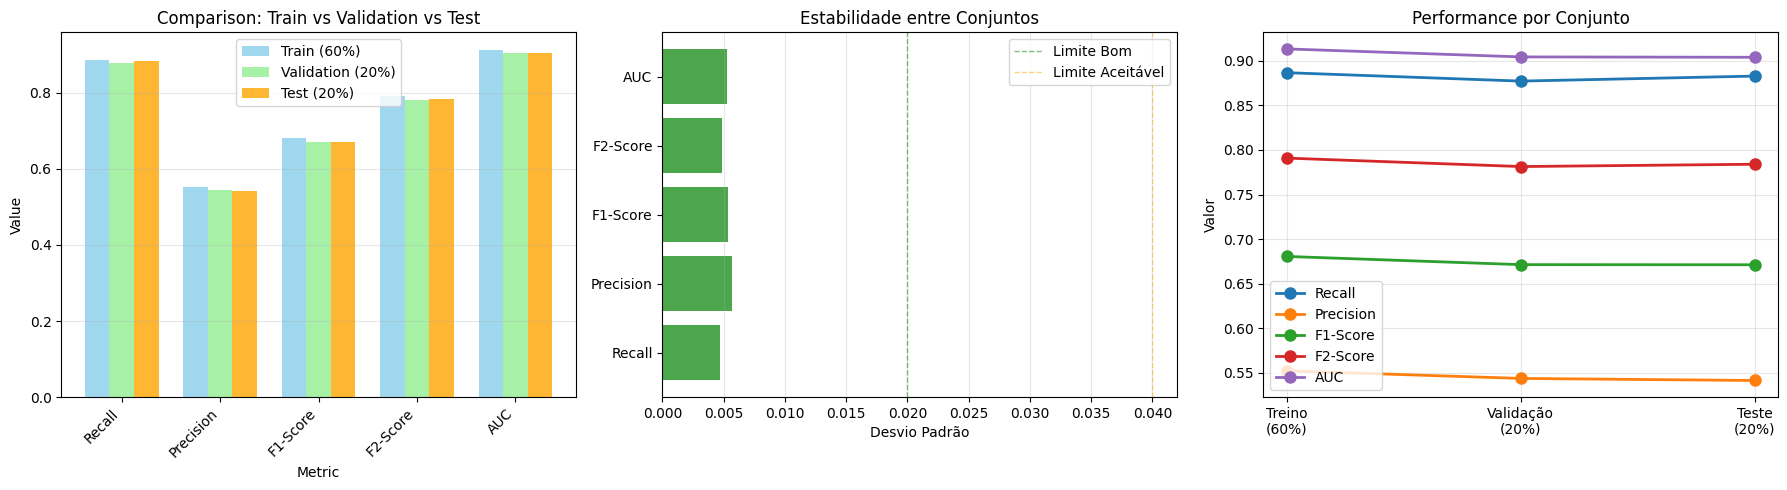


✅ ANÁLISE COMPLETA CONCLUÍDA

💡 Resumo:
   • Os 3 conjuntos têm 29,305, 9,768 e 9,769 registros
   • A melhor combinação usa 11 features
   • Desvio padrão médio entre conjuntos: 0.0052
   • F2-Score médio: 0.7854


In [0]:
# Comparar performance do melhor modelo em TODOS os 3 conjuntos

if len(successful_results) > 0:
    print("="*100)
    print("📊 ANÁLISE COMPLETA: TREINO (60%) vs VALIDAÇÃO (20%) vs TESTE (20%)")
    print("="*100)

    # Pegar a melhor combinação
    best_combo = successful_results.iloc[0]
    best_features_str = best_combo['features']
    best_features = [f.strip() for f in best_features_str.split(',')]

    print(f"\n📋 Melhor combinação (Experimento {best_combo['experiment_id']}):")
    print(f"   Features ({len(best_features)}): {best_features}\n")

    # Separar features numéricas e binárias
    numeric_in_combo = [f for f in best_features if f in all_numeric_features]
    binary_in_combo = [f for f in best_features if f in all_binary_features]

    # Criar preprocessor
    transformers = []
    if numeric_in_combo:
        numeric_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])
        transformers.append(('num', numeric_transformer, numeric_in_combo))

    if binary_in_combo:
        binary_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent'))
        ])
        transformers.append(('bin', binary_transformer, binary_in_combo))

    preprocessor_best = ColumnTransformer(transformers=transformers)
    pipeline_best = Pipeline(steps=[
    ('preprocessor', preprocessor_best),
    # ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')) #versão 1,2,3,4
    ('classifier', XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss'))
    ])

    # ====== TREINAR ======
    X_train_best = df_train[best_features]
    pipeline_best.fit(X_train_best, y_train)

    # ====== AVALIAR NO TREINO (60%) ======
    y_train_pred = pipeline_best.predict(X_train_best)
    y_train_pred_proba = pipeline_best.predict_proba(X_train_best)[:, 1]

    recall_train = recall_score(y_train, y_train_pred)
    precision_train = precision_score(y_train, y_train_pred)
    f1_train = f1_score(y_train, y_train_pred)
    f2_train = fbeta_score(y_train, y_train_pred, beta=2)
    auc_train = roc_auc_score(y_train, y_train_pred_proba)

    # ====== AVALIAR NA VALIDAÇÃO (20%) ======
    X_val_best = df_val[best_features]
    y_val_pred = pipeline_best.predict(X_val_best)
    y_val_pred_proba = pipeline_best.predict_proba(X_val_best)[:, 1]

    recall_val = recall_score(y_val, y_val_pred)
    precision_val = precision_score(y_val, y_val_pred)
    f1_val = f1_score(y_val, y_val_pred)
    f2_val = fbeta_score(y_val, y_val_pred, beta=2)
    auc_val = roc_auc_score(y_val, y_val_pred_proba)

    # ====== AVALIAR NO TESTE (20%) ======
    X_test_best = df_test[best_features]
    y_test_pred = pipeline_best.predict(X_test_best)
    y_test_pred_proba = pipeline_best.predict_proba(X_test_best)[:, 1]

    recall_test = recall_score(y_test, y_test_pred)
    precision_test = precision_score(y_test, y_test_pred)
    f1_test = f1_score(y_test, y_test_pred)
    f2_test = fbeta_score(y_test, y_test_pred, beta=2)
    auc_test = roc_auc_score(y_test, y_test_pred_proba)

    # ====== CRIAR DATAFRAME DE COMPARAÇÃO ======
    comparison_3sets = pd.DataFrame({
        'Métrica': ['Recall', 'Precision', 'F1-Score', 'F2-Score', 'AUC'],
        'Treino (60%)': [recall_train, precision_train, f1_train, f2_train, auc_train],
        'Validação (20%)': [recall_val, precision_val, f1_val, f2_val, auc_val],
        'Teste (20%)': [recall_test, precision_test, f1_test, f2_test, auc_test]
    })

    # Calcular desvio padrão entre os 3 conjuntos (estabilidade)
    comparison_3sets['Desvio Padrão'] = comparison_3sets[['Treino (60%)', 'Validação (20%)', 'Teste (20%)']].std(axis=1)
    comparison_3sets['Range'] = comparison_3sets[['Treino (60%)', 'Validação (20%)', 'Teste (20%)']].max(axis=1) - \
                                comparison_3sets[['Treino (60%)', 'Validação (20%)', 'Teste (20%)']].min(axis=1)

    print("\n" + "="*100)
    print("📊 COMPARAÇÃO: TREINO vs VALIDAÇÃO vs TESTE")
    print("="*100)
    display(comparison_3sets.style.format({
        'Treino (60%)': '{:.4f}',
        'Validação (20%)': '{:.4f}',
        'Teste (20%)': '{:.4f}',
        'Desvio Padrão': '{:.4f}',
        'Range': '{:.4f}'
    }).background_gradient(subset=['Desvio Padrão', 'Range'], cmap='RdYlGn_r'))

    # Interpretação
    print("\n" + "="*100)
    print("🔍 INTERPRETAÇÃO")
    print("="*100)

    avg_std = comparison_3sets['Desvio Padrão'].mean()
    avg_range = comparison_3sets['Range'].mean()

    print(f"\n📈 Desvio Padrão Médio: {avg_std:.4f}")
    print(f"📈 Range Médio: {avg_range:.4f}\n")

    if avg_std < 0.02:
        print("✅ EXCELENTE CONSISTÊNCIA")
        print("   O modelo performa de forma muito similar nos 3 conjuntos.")
        print("   Alta confiabilidade e boa generalização!")
    elif avg_std < 0.04:
        print("✅ BOA CONSISTÊNCIA")
        print("   O modelo performa de forma consistente nos 3 conjuntos.")
        print("   Generalização adequada.")
    else:
        print("⚠️ VARIABILIDADE DETECTADA")
        print("   Há diferenças significativas entre os conjuntos.")
        print("   Revisar possível overfitting ou underfitting.")

    # Análise específica por conjunto
    print("\n🎯 Análise Detalhada (F2-Score):")
    f2_values = [f2_train, f2_val, f2_test]
    f2_labels = ['Treino', 'Validação', 'Teste']
    best_set_idx = f2_values.index(max(f2_values))
    worst_set_idx = f2_values.index(min(f2_values))

    print(f"   • Melhor: {f2_labels[best_set_idx]} ({f2_values[best_set_idx]:.4f})")
    print(f"   • Pior: {f2_labels[worst_set_idx]} ({f2_values[worst_set_idx]:.4f})")
    print(f"   • Diferença: {max(f2_values) - min(f2_values):.4f}")

    if best_set_idx == 0:
        print("\n   ⚠️ Treino tem melhor performance → Possível leve overfitting")
    elif f2_val > f2_train and f2_test > f2_train:
        print("\n   ⚠️ Validação e Teste superam Treino → Verificar dados ou randomização")
    else:
        print("\n   ✅ Performance equilibrada entre os conjuntos")

    # Visualização
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Gráfico 1: Comparação por Métrica
    metrics = comparison_3sets['Métrica']
    x = range(len(metrics))
    width = 0.25

    axes[0].bar([i - width for i in x], comparison_3sets['Treino (60%)'], width,
                label='Train (60%)', alpha=0.8, color='skyblue')
    axes[0].bar([i for i in x], comparison_3sets['Validação (20%)'], width,
                label='Validation (20%)', alpha=0.8, color='lightgreen')
    axes[0].bar([i + width for i in x], comparison_3sets['Teste (20%)'], width,
                label='Test (20%)', alpha=0.8, color='orange')
    axes[0].set_xlabel('Metric')
    axes[0].set_ylabel('Value')
    axes[0].set_title('Comparison: Train vs Validation vs Test')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics, rotation=45, ha='right')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')

    # Gráfico 2: Desvio Padrão (Estabilidade)
    colors_std = ['green' if std < 0.02 else 'orange' if std < 0.04 else 'red'
                  for std in comparison_3sets['Desvio Padrão']]
    axes[1].barh(metrics, comparison_3sets['Desvio Padrão'], color=colors_std, alpha=0.7)
    axes[1].axvline(0.02, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Limite Bom')
    axes[1].axvline(0.04, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Limite Aceitável')
    axes[1].set_xlabel('Desvio Padrão')
    axes[1].set_title('Estabilidade entre Conjuntos')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='x')

    # Gráfico 3: Linha - Evolução por Conjunto
    for i, metric in enumerate(metrics):
        values = [comparison_3sets.iloc[i]['Treino (60%)'],
                 comparison_3sets.iloc[i]['Validação (20%)'],
                 comparison_3sets.iloc[i]['Teste (20%)']]
        axes[2].plot(['Treino\n(60%)', 'Validação\n(20%)', 'Teste\n(20%)'], values,
                     marker='o', label=metric, linewidth=2, markersize=8)

    axes[2].set_ylabel('Valor')
    axes[2].set_title('Performance por Conjunto')
    axes[2].legend(loc='best')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n" + "="*100)
    print("✅ ANÁLISE COMPLETA CONCLUÍDA")
    print("="*100)
    print("\n💡 Resumo:")
    print(f"   • Os 3 conjuntos têm {len(df_train):,}, {len(df_val):,} e {len(df_test):,} registros")
    print(f"   • A melhor combinação usa {len(best_features)} features")
    print(f"   • Desvio padrão médio entre conjuntos: {avg_std:.4f}")
    print(f"   • F2-Score médio: {(f2_train + f2_val + f2_test)/3:.4f}")

else:
    print("⚠️ Execute primeiro a célula 21 (experimentos) para ter resultados disponíveis.")

## Confusion Matrix & Precision-Recall Analysis

🏆 Melhor experimento: 22
   Features (11): ['age', 'education-num', 'hours-per-week', 'relationship_ord', 'marital_status_ord', 'is_capital_gain', 'capital-loss', 'is_wife', 'workclass_ord', 'fnlwgt', 'is_native-country_missing']
   F2-Score: 0.7787
   Precision: 0.5453
   Recall: 0.8721

Confusion Matrix (valores absolutos):
[[5683 1748]
 [ 274 2064]]


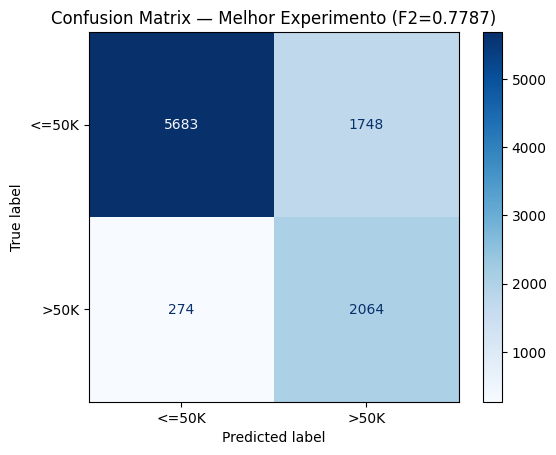

In [0]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Garantir que estamos pegando o MELHOR de TODOS os experimentos
successful_results = results_df[results_df['status'] == 'success'].sort_values('f2_cv_mean', ascending=False)

# Check if there are any successful experiments
if len(successful_results) == 0:
    print("❌ ERRO: Nenhum experimento foi executado com sucesso.")
    print(f"\nTotal de experimentos: {len(results_df)}")
    print(f"Experimentos bem-sucedidos: 0")
    print("\n📋 SOLUÇÃO:")
    print("   1. Verifique Cell 11 (Run All Experiments) para ver os erros dos experimentos")
    print("   2. Corrija os erros e execute Cell 11 novamente")
    print("   3. Depois execute esta célula novamente")
    raise ValueError("Nenhum experimento bem-sucedido encontrado")

best_combo = successful_results.iloc[0]
best_features = [f.strip() for f in best_combo['features'].split(',')]

print(f"🏆 Melhor experimento: {best_combo['experiment_id']}")
print(f"   Features ({len(best_features)}): {best_features}")
print(f"   F2-Score: {best_combo['f2_cv_mean']:.4f}")
print(f"   Precision: {best_combo['precision_cv_mean']:.4f}")
print(f"   Recall: {best_combo['recall_cv_mean']:.4f}\n")

# 2. Recriar o preprocessor para essa combinação específica
numeric_in_combo = [f for f in best_features if f in all_numeric_features]
binary_in_combo = [f for f in best_features if f in all_binary_features]

transformers = []
if numeric_in_combo:
    transformers.append(('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_in_combo))

if binary_in_combo:
    transformers.append(('bin', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ]), binary_in_combo))

preprocessor_best = ColumnTransformer(transformers=transformers)

# 3. Treinar o pipeline com a melhor combinação
pipeline_best = Pipeline(steps=[
    ('preprocessor', preprocessor_best),
    # ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')) #versão 1,2,3,4
    ('classifier', XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss'))
])

X_train_best = df_train[best_features]
X_test_best = df_test[best_features]

pipeline_best.fit(X_train_best, y_train)

# 4. Prever e gerar Confusion Matrix
y_test_pred_best = pipeline_best.predict(X_test_best)
y_test_pred_proba_best = pipeline_best.predict_proba(X_test_best)[:, 1]

cm = confusion_matrix(y_test, y_test_pred_best)
print("Confusion Matrix (valores absolutos):")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — Melhor Experimento (F2={best_combo["f2_cv_mean"]:.4f})')
plt.show()

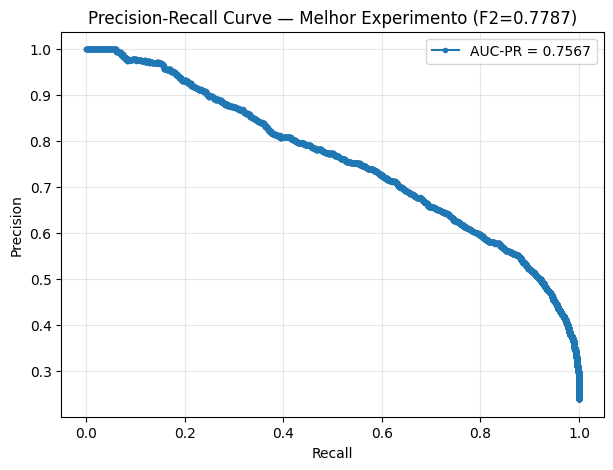

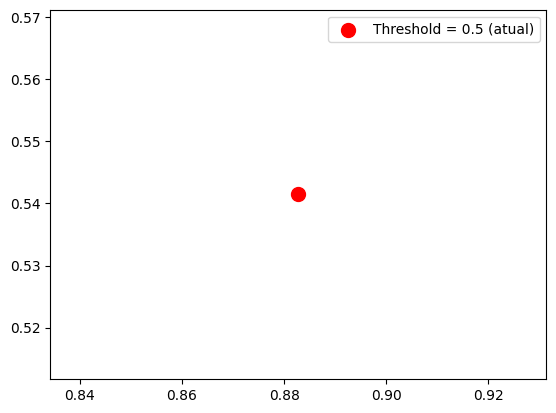

In [0]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_test_pred_proba_best)
auc_pr = average_precision_score(y_test, y_test_pred_proba_best)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, marker='.', label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve — Melhor Experimento (F2={best_combo["f2_cv_mean"]:.4f})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Marcar o ponto do threshold atual (0.5) na curva
idx_threshold_05 = (thresholds >= 0.5).argmax()
plt.scatter(recall[idx_threshold_05], precision[idx_threshold_05],
            color='red', s=100, zorder=5, label='Threshold = 0.5 (atual)')
plt.legend()

In [0]:
from sklearn.metrics import roc_auc_score, average_precision_score

auc_roc = roc_auc_score(y_test, y_test_pred_proba)
auc_pr = average_precision_score(y_test, y_test_pred_proba)

print("AUC-ROC:", auc_roc)
print("AUC-PR:", auc_pr)

AUC-ROC: 0.9039022134518667
AUC-PR: 0.7566581456151532


## Feature Importance Analysis

🎯 FEATURE IMPORTANCE - Melhor Modelo (XGBoost)

📋 Melhor combinação (Experimento 22):
   Features (11): ['age', 'education-num', 'hours-per-week', 'relationship_ord', 'marital_status_ord', 'is_capital_gain', 'capital-loss', 'is_wife', 'workclass_ord', 'fnlwgt', 'is_native-country_missing']
   F2-Score (CV): 0.7787

🚀 XGBOOST - Feature Importance

✅ Feature Importance (ordenadas por importância):


,Feature,Importance,Importance_Pct
4,marital_status_ord,0.3625,36.25%
3,relationship_ord,0.3524,35.24%
1,education-num,0.1001,10.01%
8,is_capital_gain,0.0538,5.38%
0,age,0.0341,3.41%
5,capital-loss,0.0262,2.62%
2,hours-per-week,0.0254,2.54%
9,is_wife,0.0189,1.89%
6,workclass_ord,0.0121,1.21%
10,is_native-country_missing,0.0078,0.78%


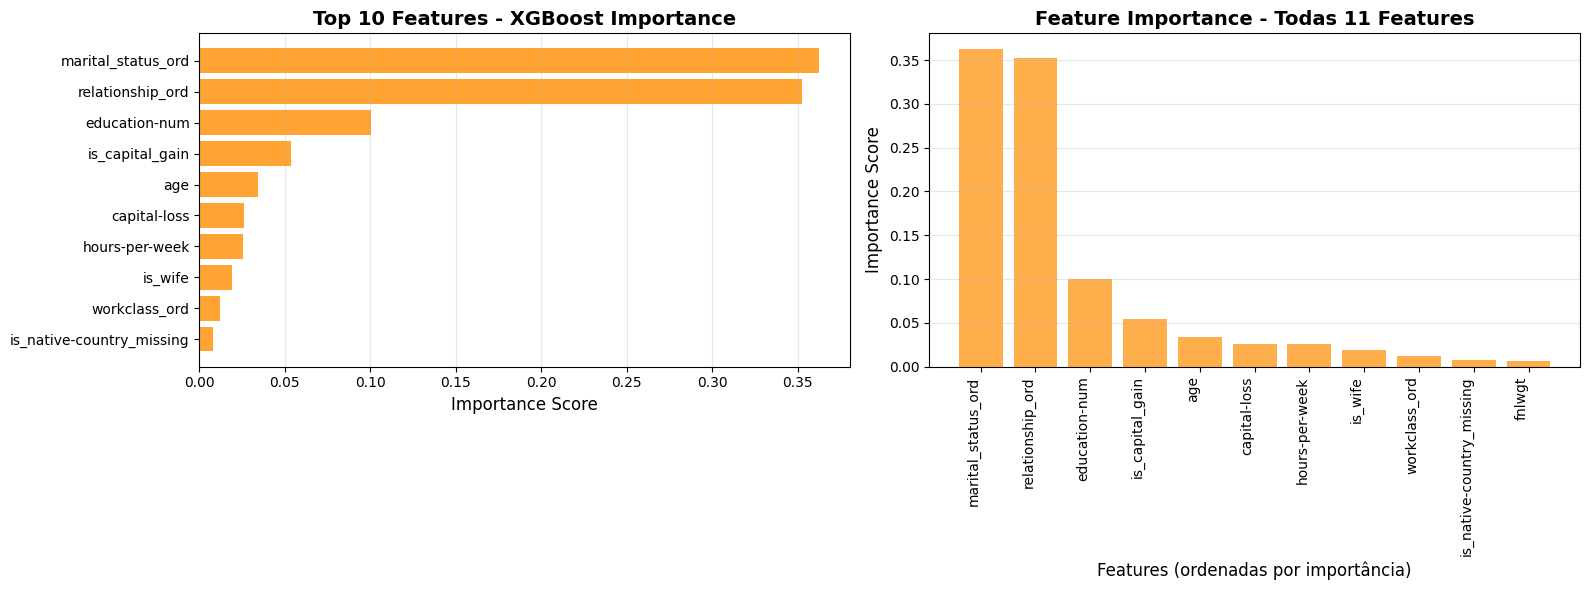


✅ ANÁLISE CONCLUÍDA

💡 Resumo:
   • Feature mais importante: marital_status_ord (0.3625 - 36.25%)
   • Top 3 features representam 81.50% da importância total
   • Top 5 features representam 90.30% da importância total


In [0]:
# Feature Importance for Best Model (XGBoost)
import numpy as np
import matplotlib.pyplot as plt

if len(successful_results) > 0:
    print("="*100)
    print("🎯 FEATURE IMPORTANCE - Melhor Modelo (XGBoost)")
    print("="*100)

    # Pegar a melhor combinação
    best_combo = successful_results.iloc[0]
    best_features_str = best_combo['features']
    best_features = [f.strip() for f in best_features_str.split(',')]

    print(f"\n📋 Melhor combinação (Experimento {best_combo['experiment_id']}):")
    print(f"   Features ({len(best_features)}): {best_features}")
    print(f"   F2-Score (CV): {best_combo['f2_cv_mean']:.4f}\n")

    # Separar features numéricas e binárias
    numeric_in_combo = [f for f in best_features if f in all_numeric_features]
    binary_in_combo = [f for f in best_features if f in all_binary_features]

    # Criar preprocessor
    transformers = []
    if numeric_in_combo:
        numeric_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])
        transformers.append(('num', numeric_transformer, numeric_in_combo))

    if binary_in_combo:
        binary_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent'))
        ])
        transformers.append(('bin', binary_transformer, binary_in_combo))

    preprocessor_best = ColumnTransformer(transformers=transformers)

    # ====== XGBOOST ======
    print("="*100)
    print("🚀 XGBOOST - Feature Importance")
    print("="*100)

    pipeline_xgb = Pipeline(steps=[
        ('preprocessor', preprocessor_best),
        # ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')) #versão 1,2,3,4
        ('classifier', XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss'))
    ])

    X_train_best = df_train[best_features]
    pipeline_xgb.fit(X_train_best, y_train)

    # Obter importâncias do XGBoost
    xgb_importances = pipeline_xgb.named_steps['classifier'].feature_importances_
    feature_names = numeric_in_combo + binary_in_combo

    xgb_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': xgb_importances,
        'Importance_Pct': (xgb_importances / xgb_importances.sum()) * 100
    }).sort_values('Importance', ascending=False)

    print("\n✅ Feature Importance (ordenadas por importância):")
    display(xgb_importance_df.style.format({
        'Importance': '{:.4f}',
        'Importance_Pct': '{:.2f}%'
    }).background_gradient(subset=['Importance'], cmap='YlOrRd'))

    # ====== VISUALIZAÇÃO ======
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfico 1: Top 10 Features - Bar Chart Horizontal
    xgb_plot_data = xgb_importance_df.head(10).sort_values('Importance')
    axes[0].barh(xgb_plot_data['Feature'], xgb_plot_data['Importance'], color='darkorange', alpha=0.8)
    axes[0].set_xlabel('Importance Score', fontsize=12)
    axes[0].set_title('Top 10 Features - XGBoost Importance', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='x')

    # Gráfico 2: Todas Features - Bar Chart Vertical
    xgb_sorted = xgb_importance_df.sort_values('Importance', ascending=False)
    axes[1].bar(range(len(xgb_sorted)), xgb_sorted['Importance'], color='darkorange', alpha=0.7)
    axes[1].set_xlabel('Features (ordenadas por importância)', fontsize=12)
    axes[1].set_ylabel('Importance Score', fontsize=12)
    axes[1].set_title(f'Feature Importance - Todas {len(best_features)} Features', fontsize=14, fontweight='bold')
    axes[1].set_xticks(range(len(xgb_sorted)))
    axes[1].set_xticklabels(xgb_sorted['Feature'], rotation=90, ha='right')
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print("\n" + "="*100)
    print("✅ ANÁLISE CONCLUÍDA")
    print("="*100)
    print(f"\n💡 Resumo:")
    print(f"   • Feature mais importante: {xgb_importance_df.iloc[0]['Feature']} ({xgb_importance_df.iloc[0]['Importance']:.4f} - {xgb_importance_df.iloc[0]['Importance_Pct']:.2f}%)")
    print(f"   • Top 3 features representam {xgb_importance_df.head(3)['Importance_Pct'].sum():.2f}% da importância total")
    print(f"   • Top 5 features representam {xgb_importance_df.head(5)['Importance_Pct'].sum():.2f}% da importância total")

else:
    print("⚠️ Execute primeiro a célula 11 (experimentos) para ter resultados disponíveis.")

## ROC CURVE

📊 ROC CURVE - XGBoost Best Model

📋 Melhor combinação (Experimento 22):
   Features (11): ['age', 'education-num', 'hours-per-week', 'relationship_ord', 'marital_status_ord', 'is_capital_gain', 'capital-loss', 'is_wife', 'workclass_ord', 'fnlwgt', 'is_native-country_missing']

Treinando XGBoost...

📈 ROC CURVE - XGBoost


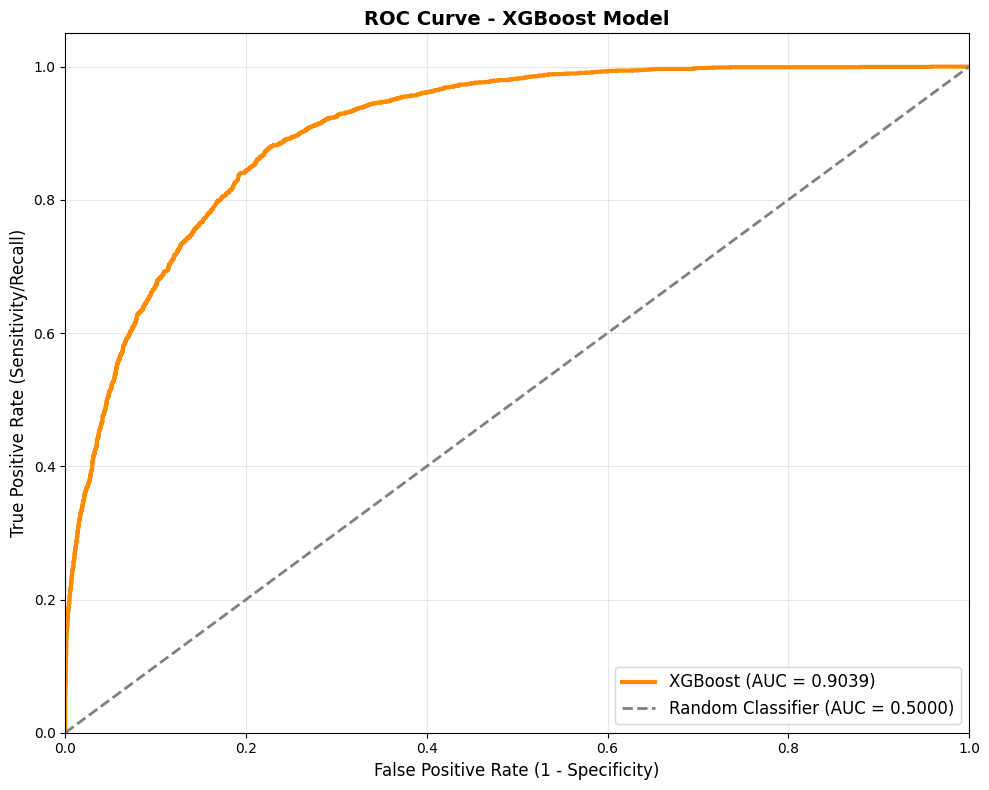


📊 MÉTRICAS DO MODELO XGBOOST


,Métrica,Valor
0,AUC,0.9039
1,Recall,0.8828
2,Precision,0.5414
3,F1-Score,0.6712
4,F2-Score,0.7840



🔍 INTERPRETAÇÃO

📈 AUC-ROC: 0.9039
📈 Recall: 0.8828
📈 Precision: 0.5414
📈 F2-Score: 0.7840

✅ DESEMPENHO EXCELENTE
   O modelo XGBoost apresenta AUC superior a 0.90.
   Isso indica excelente capacidade de discriminação entre classes.

✅ ANÁLISE ROC CONCLUÍDA


In [0]:
# ROC Curve: XGBoost Best Model
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

if len(successful_results) > 0:
    print("="*100)
    print("📊 ROC CURVE - XGBoost Best Model")
    print("="*100)

    # Pegar a melhor combinação
    best_combo = successful_results.iloc[0]
    best_features_str = best_combo['features']
    best_features = [f.strip() for f in best_features_str.split(',')]

    print(f"\n📋 Melhor combinação (Experimento {best_combo['experiment_id']}):")
    print(f"   Features ({len(best_features)}): {best_features}\n")

    # Separar features numéricas e binárias
    numeric_in_combo = [f for f in best_features if f in all_numeric_features]
    binary_in_combo = [f for f in best_features if f in all_binary_features]

    # Criar preprocessor
    transformers = []
    if numeric_in_combo:
        numeric_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])
        transformers.append(('num', numeric_transformer, numeric_in_combo))

    if binary_in_combo:
        binary_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent'))
        ])
        transformers.append(('bin', binary_transformer, binary_in_combo))

    preprocessor_best = ColumnTransformer(transformers=transformers)

    # ====== XGBOOST ======
    print("Treinando XGBoost...")
    pipeline_xgb = Pipeline(steps=[
        ('preprocessor', preprocessor_best),
        # ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')) #versão 1,2,3,4
        ('classifier', XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss'))
    ])

    X_train_best = df_train[best_features]
    X_test_best = df_test[best_features]

    pipeline_xgb.fit(X_train_best, y_train)
    y_pred_proba_xgb = pipeline_xgb.predict_proba(X_test_best)[:, 1]

    # Calcular ROC para XGBoost
    fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)
    auc_xgb = auc(fpr_xgb, tpr_xgb)

    # ====== VISUALIZAÇÃO ======
    print("\n" + "="*100)
    print("📈 ROC CURVE - XGBoost")
    print("="*100)

    plt.figure(figsize=(10, 8))

    # Plot XGBoost
    plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=3,
             label=f'XGBoost (AUC = {auc_xgb:.4f})')

    # Plot linha diagonal (classificador aleatório)
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--',
             label='Random Classifier (AUC = 0.5000)')

    # Configurações do gráfico
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity/Recall)', fontsize=12)
    plt.title('ROC Curve - XGBoost Model', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ====== MÉTRICAS DETALHADAS ======
    print("\n" + "="*100)
    print("📊 MÉTRICAS DO MODELO XGBOOST")
    print("="*100)

    # Calcular todas as métricas para XGBoost
    from sklearn.metrics import recall_score, precision_score, f1_score, fbeta_score

    y_pred_xgb = pipeline_xgb.predict(X_test_best)

    metrics_data = {
        'Métrica': ['AUC', 'Recall', 'Precision', 'F1-Score', 'F2-Score'],
        'Valor': [
            auc_xgb,
            recall_score(y_test, y_pred_xgb),
            precision_score(y_test, y_pred_xgb),
            f1_score(y_test, y_pred_xgb),
            fbeta_score(y_test, y_pred_xgb, beta=2)
        ]
    }

    metrics_df = pd.DataFrame(metrics_data)
    display(metrics_df.style.format({'Valor': '{:.4f}'}).background_gradient(subset=['Valor'], cmap='YlOrRd'))

    # ====== INTERPRETAÇÃO ======
    print("\n" + "="*100)
    print("🔍 INTERPRETAÇÃO")
    print("="*100)

    print(f"\n📈 AUC-ROC: {auc_xgb:.4f}")
    print(f"📈 Recall: {recall_score(y_test, y_pred_xgb):.4f}")
    print(f"📈 Precision: {precision_score(y_test, y_pred_xgb):.4f}")
    print(f"📈 F2-Score: {fbeta_score(y_test, y_pred_xgb, beta=2):.4f}\n")

    if auc_xgb >= 0.90:
        print("✅ DESEMPENHO EXCELENTE")
        print("   O modelo XGBoost apresenta AUC superior a 0.90.")
        print("   Isso indica excelente capacidade de discriminação entre classes.")
    elif auc_xgb >= 0.80:
        print("✅ DESEMPENHO BOM")
        print("   O modelo XGBoost apresenta AUC entre 0.80 e 0.90.")
        print("   Boa capacidade de discriminação entre classes.")
    elif auc_xgb >= 0.70:
        print("⚠️ DESEMPENHO MODERADO")
        print("   O modelo XGBoost apresenta AUC entre 0.70 e 0.80.")
        print("   Capacidade moderada de discriminação entre classes.")
    else:
        print("⚠️ DESEMPENHO FRACO")
        print("   O modelo XGBoost apresenta AUC abaixo de 0.70.")
        print("   Considere ajustar hiperparâmetros ou revisar features.")

    print("\n" + "="*100)
    print("✅ ANÁLISE ROC CONCLUÍDA")
    print("="*100)

else:
    print("⚠️ Execute primeiro a célula 11 (experimentos) para ter resultados disponíveis.")